In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

os.chdir(r'D:\End-to-end-ML\Customer-Risk-Escalation-Engine')

warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm




In [2]:
X_train = pd.read_csv('data/processed_data/X_train.csv')
X_test  = pd.read_csv('data/processed_data/X_test.csv')
y_train = pd.read_csv('data/processed_data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed_data/y_test.csv').squeeze()

print("Data loaded ✅")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Data loaded ✅
X_train : (80000, 12)
X_test  : (20000, 12)


In [3]:
mlflow.set_experiment("customer_escalation_tabular")
print("MLflow experiment set ✅")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

Traceback (most recent call last):
  File "d:\End-to-end-ML\Customer-Risk-Escalation-Engine\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\End-to-end-ML\Customer-Risk-Escalation-Engine\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\End-to-end-ML\Customer-Risk-Escalation-Engine\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\End-to-end-ML\Customer-Risk-Escalation-Engine\venv\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, 

MLflow experiment set ✅
Tracking URI: file:///D:/End-to-end-ML/Customer-Risk-Escalation-Engine/mlruns


In [4]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "f1_score"  : round(f1_score(y_test, y_pred), 4), # type: ignore
        "precision" : round(precision_score(y_test, y_pred), 4), # type: ignore
        "recall"    : round(recall_score(y_test, y_pred), 4), # type: ignore
        "roc_auc"   : round(roc_auc_score(y_test, y_pred_prob), 4)
    }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {metrics['accuracy']}")
    print(f"  F1 Score  : {metrics['f1_score']}")
    print(f"  Precision : {metrics['precision']}")
    print(f"  Recall    : {metrics['recall']}")
    print(f"  ROC AUC   : {metrics['roc_auc']}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Not Escalated', 'Escalated']))

    return metrics, y_pred, y_pred_prob

In [5]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Escalated', 'Escalated'],
        yticklabels=['Not Escalated', 'Escalated']
    )
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, model_name, top_n=20):
    importance = pd.DataFrame({
        'feature'   : feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=importance,
        x='importance',
        y='feature',
        palette='viridis'
    )
    plt.title(f'{model_name} — Top {top_n} Important Features', fontsize=13)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return importance


def plot_roc_curve(y_test, y_pred_prob, model_name):
    RocCurveDisplay.from_predictions(
        y_test,
        y_pred_prob,
        name=model_name
    )
    plt.title(f'ROC Curve — {model_name}')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
    plt.tight_layout()
    plt.show()

2026/07/06 00:12:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 00:12:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Decision Tree — Evaluation Results
  Accuracy  : 0.7259
  F1 Score  : 0.3739
  Precision : 0.2429
  Recall    : 0.8116
  ROC AUC   : 0.836
               precision    recall  f1-score   support

Not Escalated       0.97      0.72      0.82     17983
    Escalated       0.24      0.81      0.37      2017

     accuracy                           0.73     20000
    macro avg       0.61      0.76      0.60     20000
 weighted avg       0.90      0.73      0.78     20000

MLflow run logged ✅


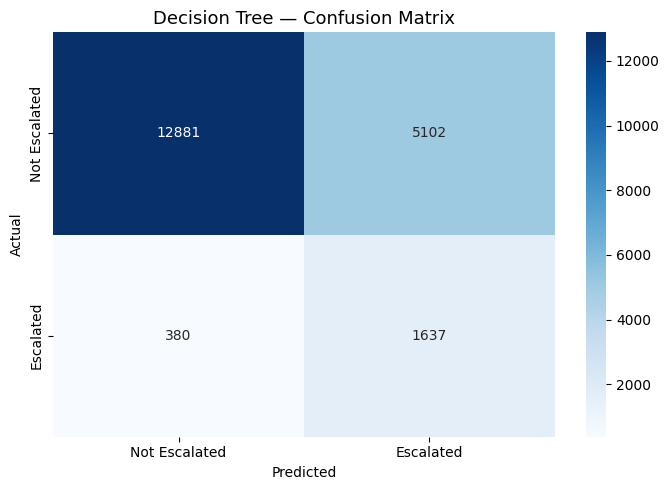

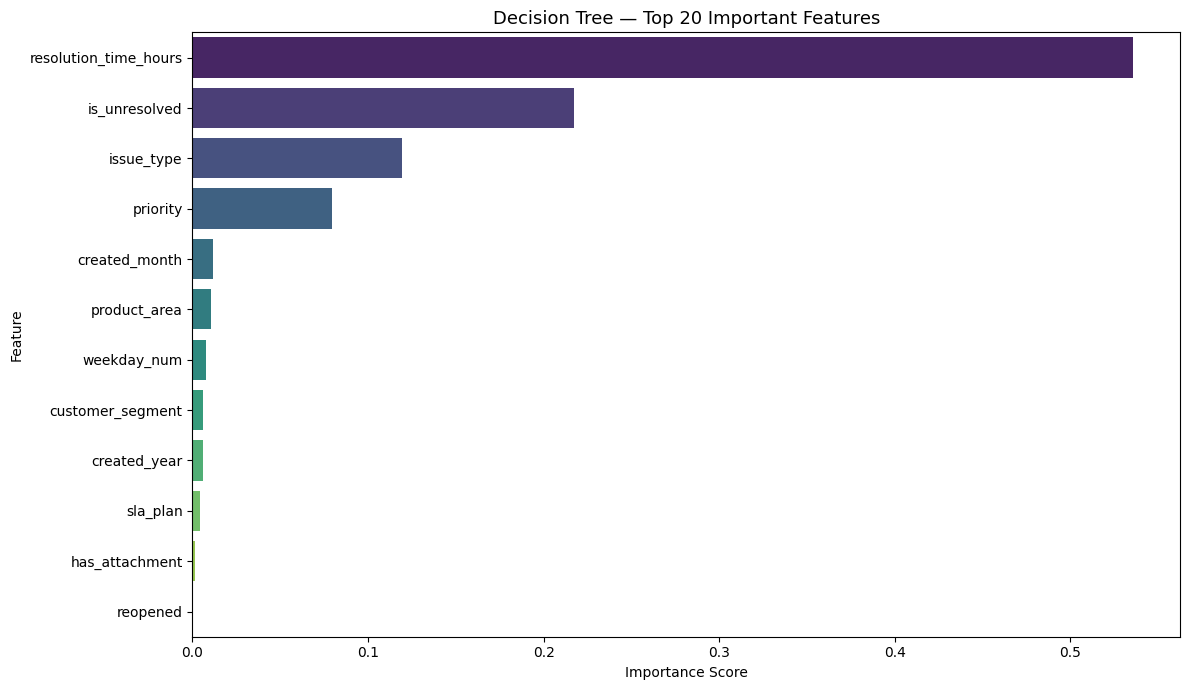

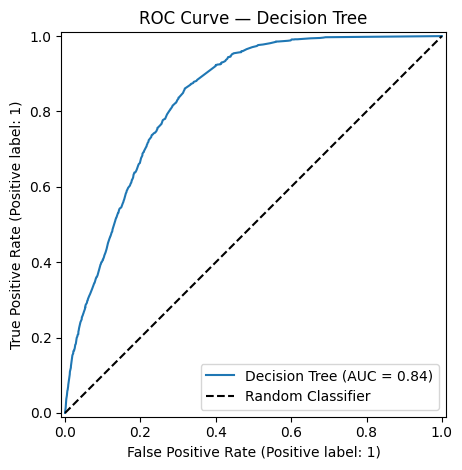

In [6]:
dt_params = {
    "max_depth"        : 10,
    "min_samples_leaf" : 50,
    'class_weight'     :'balanced',
    "random_state"     : 42
}

with mlflow.start_run(run_name="Decision_Tree"):

    dt_model = DecisionTreeClassifier(**dt_params)
    dt_model.fit(X_train, y_train)

    dt_metrics, dt_pred, dt_prob = evaluate_model(
        dt_model, X_test, y_test,
        model_name="Decision Tree"
    )

    mlflow.log_params(dt_params)
    mlflow.log_metrics(dt_metrics)
    mlflow.sklearn.log_model(dt_model, "decision_tree")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, dt_pred, "Decision Tree")
plot_feature_importance(dt_model, X_train.columns.tolist(), "Decision Tree")
plot_roc_curve(y_test, dt_prob, "Decision Tree")

2026/07/06 00:12:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  Random Forest — Evaluation Results
  Accuracy  : 0.7252
  F1 Score  : 0.3724
  Precision : 0.2419
  Recall    : 0.8081
  ROC AUC   : 0.8317
               precision    recall  f1-score   support

Not Escalated       0.97      0.72      0.82     17983
    Escalated       0.24      0.81      0.37      2017

     accuracy                           0.73     20000
    macro avg       0.61      0.76      0.60     20000
 weighted avg       0.90      0.73      0.78     20000



2026/07/06 00:12:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged ✅


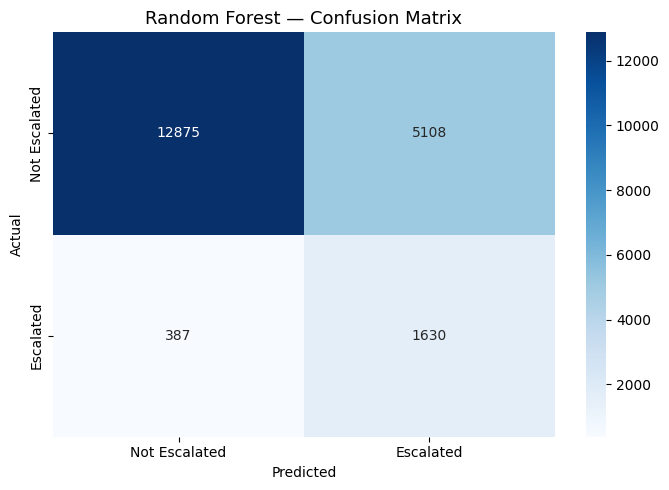

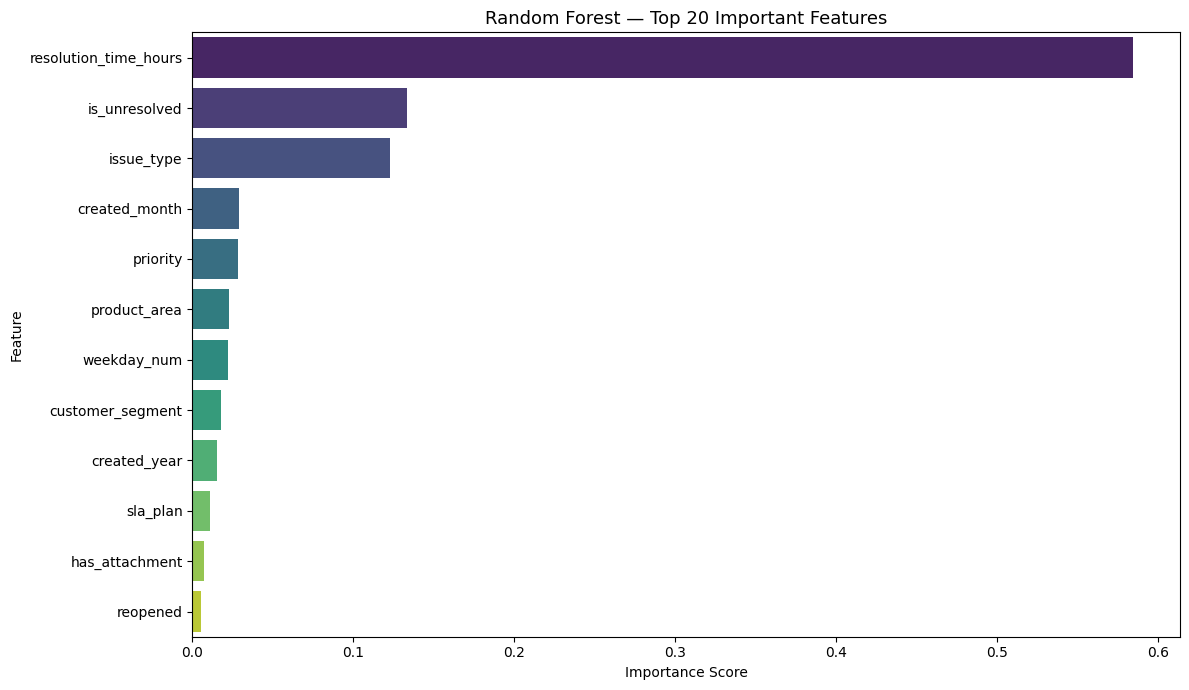

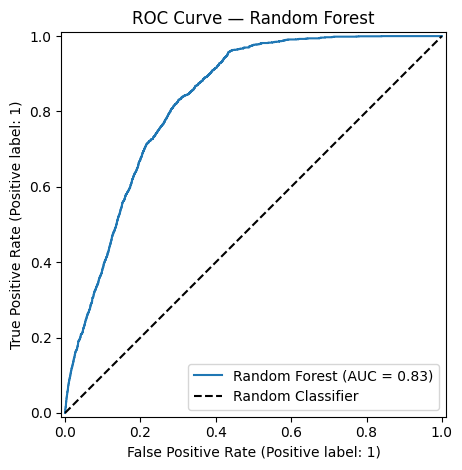

In [7]:
rf_params = {
    "n_estimators" : 200,
    "max_depth"    : 10,
    "n_jobs"       : -1,
    'class_weight'     :'balanced',
    "random_state" : 42
}

with mlflow.start_run(run_name="Random_Forest"):

    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train, y_train)

    rf_metrics, rf_pred, rf_prob = evaluate_model(
        rf_model, X_test, y_test,
        model_name="Random Forest"
    )

    mlflow.log_params(rf_params)
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(rf_model, "random_forest")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, rf_pred, "Random Forest")
plot_feature_importance(rf_model, X_train.columns.tolist(), "Random Forest")
plot_roc_curve(y_test, rf_prob, "Random Forest")

2026/07/06 00:12:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Baseline — Evaluation Results
  Accuracy  : 0.7177
  F1 Score  : 0.3724
  Precision : 0.24
  Recall    : 0.8304
  ROC AUC   : 0.8419
               precision    recall  f1-score   support

Not Escalated       0.97      0.71      0.82     17983
    Escalated       0.24      0.83      0.37      2017

     accuracy                           0.72     20000
    macro avg       0.61      0.77      0.60     20000
 weighted avg       0.90      0.72      0.77     20000

MLflow run logged ✅


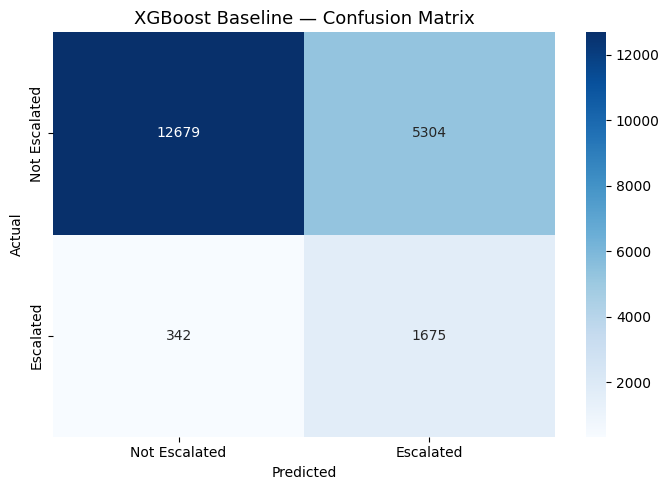

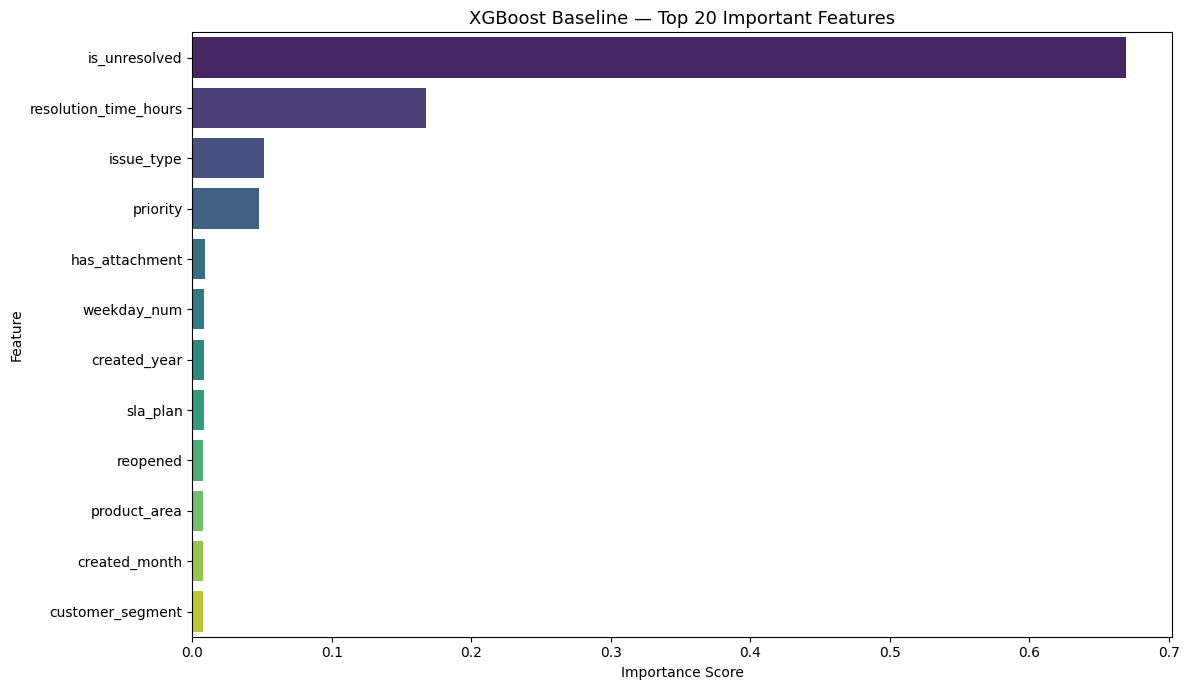

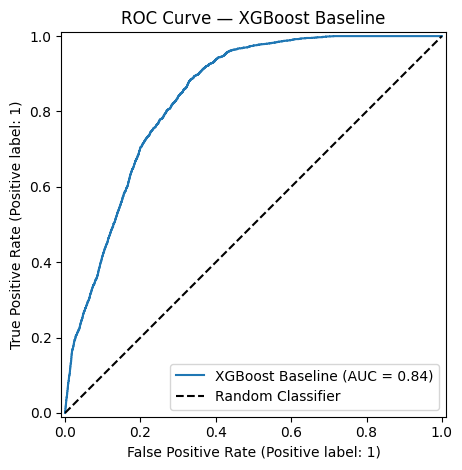

In [8]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb_baseline_params = {
    "n_estimators"      : 100,
    "max_depth"         : 6,
    "learning_rate"     : 0.1,
    "random_state"      : 42,
    "eval_metric"       : "logloss",
    'scale_pos_weight': scale,
    "use_label_encoder" : False
}

with mlflow.start_run(run_name="XGBoost_Baseline"):

    xgb_baseline = XGBClassifier(**xgb_baseline_params)
    xgb_baseline.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_base_metrics, xgb_base_pred, xgb_base_prob = evaluate_model(
        xgb_baseline, X_test, y_test,
        model_name="XGBoost Baseline"
    )

    mlflow.log_params(xgb_baseline_params)
    mlflow.log_metrics(xgb_base_metrics)
    mlflow.xgboost.log_model(xgb_baseline, "xgboost_baseline")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, xgb_base_pred, "XGBoost Baseline")
plot_feature_importance(xgb_baseline, X_train.columns.tolist(), "XGBoost Baseline")
plot_roc_curve(y_test, xgb_base_prob, "XGBoost Baseline")

2026/07/06 00:12:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Tuned — Evaluation Results
  Accuracy  : 0.7117
  F1 Score  : 0.3731
  Precision : 0.239
  Recall    : 0.8508
  ROC AUC   : 0.8435
               precision    recall  f1-score   support

Not Escalated       0.98      0.70      0.81     17983
    Escalated       0.24      0.85      0.37      2017

     accuracy                           0.71     20000
    macro avg       0.61      0.77      0.59     20000
 weighted avg       0.90      0.71      0.77     20000

MLflow run logged ✅


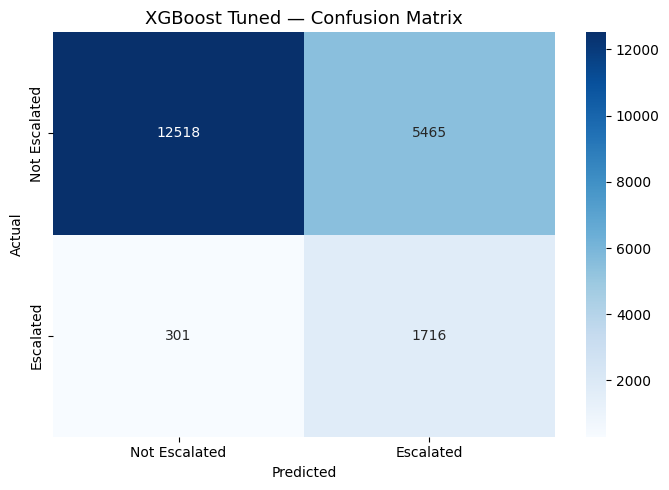

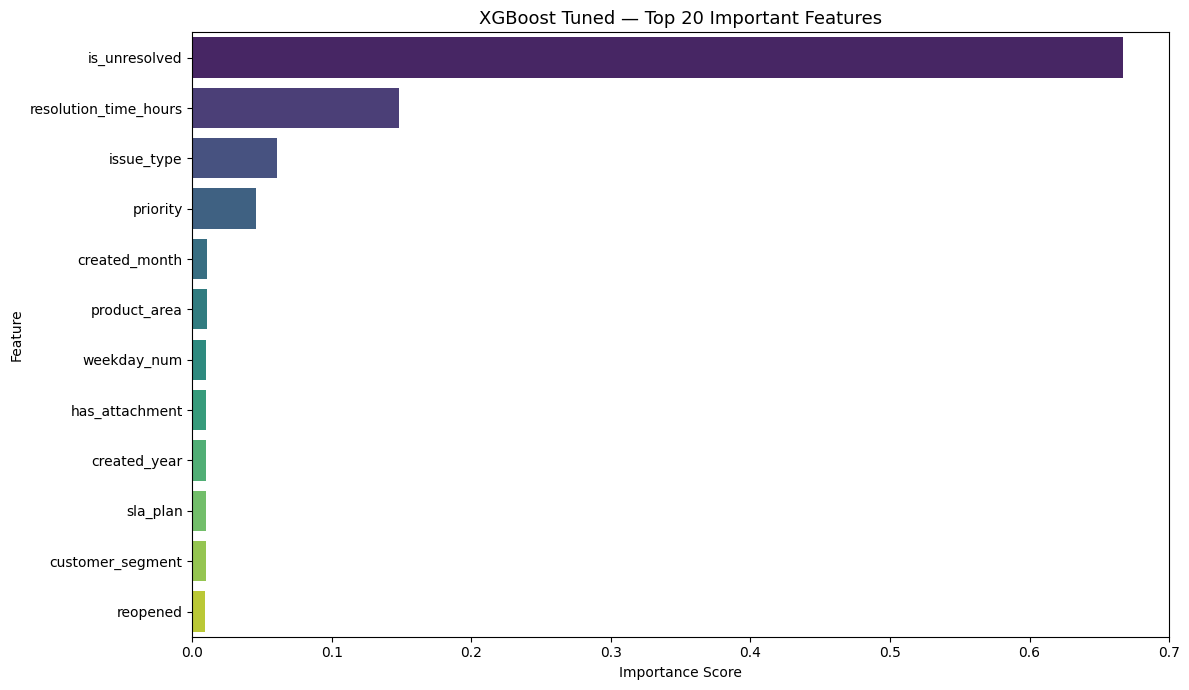

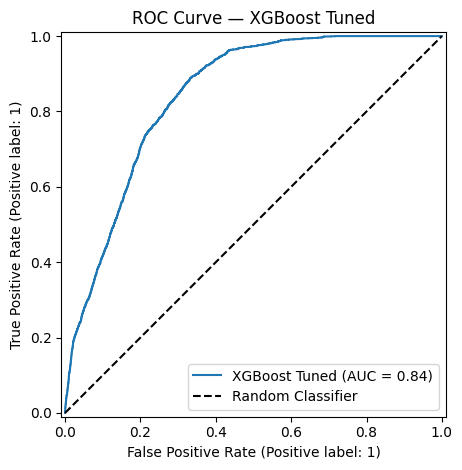

In [9]:
xgb_tuned_params = {
    "n_estimators"      : 300,
    "max_depth"         : 5,
    "learning_rate"     : 0.05,
    "min_child_weight"  : 3,
    "subsample"         : 0.8,
    "colsample_bytree"  : 0.8,
    "random_state"      : 42,
    "eval_metric"       : "logloss",
    'scale_pos_weight': scale,
    "use_label_encoder" : False
}

with mlflow.start_run(run_name="XGBoost_Tuned"):

    xgb_tuned = XGBClassifier(**xgb_tuned_params)
    xgb_tuned.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
        xgb_tuned, X_test, y_test,
        model_name="XGBoost Tuned"
    )

    mlflow.log_params(xgb_tuned_params)
    mlflow.log_metrics(xgb_tuned_metrics)
    mlflow.xgboost.log_model(xgb_tuned, "xgboost_tuned")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, xgb_tuned_pred, "XGBoost Tuned")
plot_feature_importance(xgb_tuned, X_train.columns.tolist(), "XGBoost Tuned")
plot_roc_curve(y_test, xgb_tuned_prob, "XGBoost Tuned")

2026/07/06 00:12:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/06 00:12:35 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  LightGBM — Evaluation Results
  Accuracy  : 0.7113
  F1 Score  : 0.3723
  Precision : 0.2384
  Recall    : 0.8488
  ROC AUC   : 0.8425
               precision    recall  f1-score   support

Not Escalated       0.98      0.70      0.81     17983
    Escalated       0.24      0.85      0.37      2017

     accuracy                           0.71     20000
    macro avg       0.61      0.77      0.59     20000
 weighted avg       0.90      0.71      0.77     20000

MLflow run logged ✅


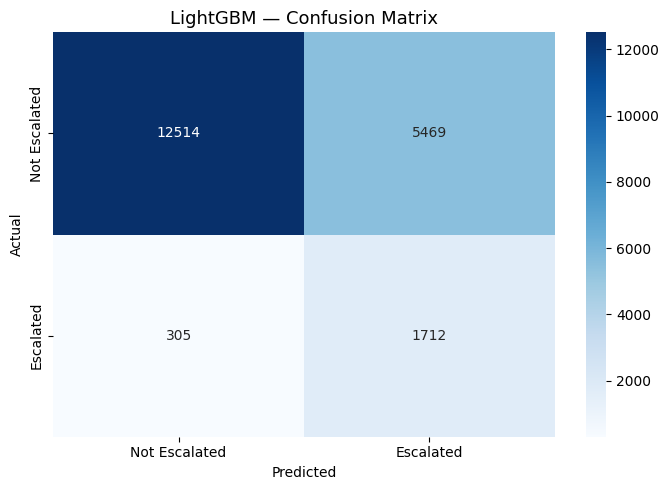

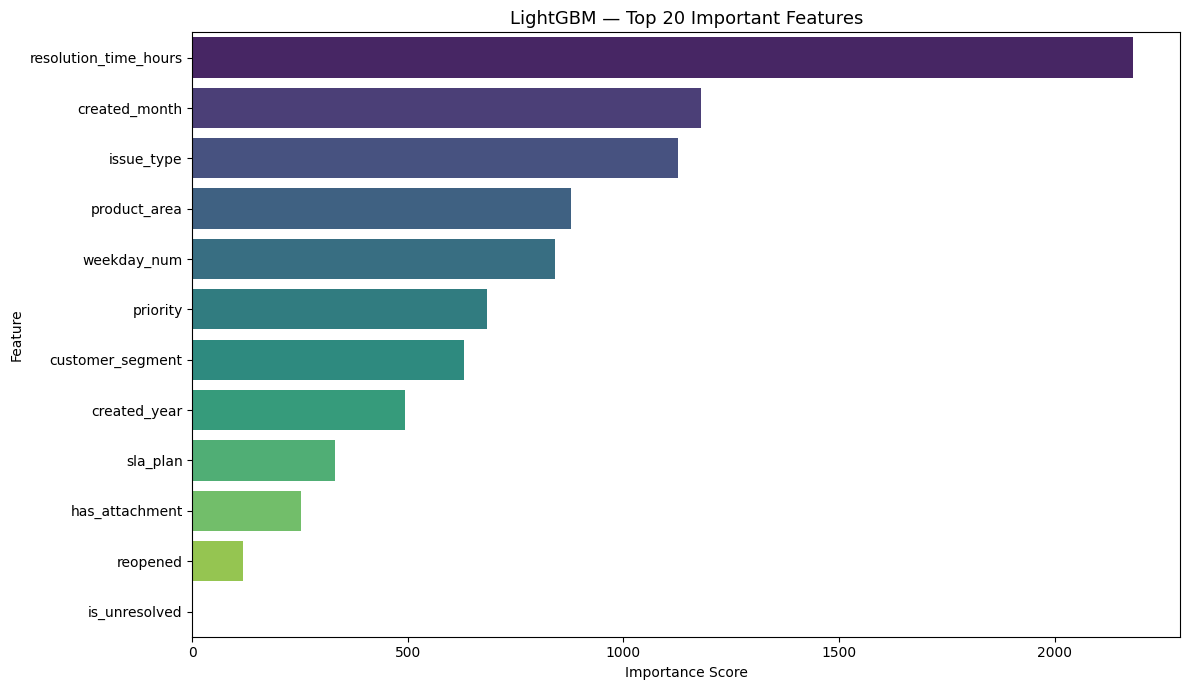

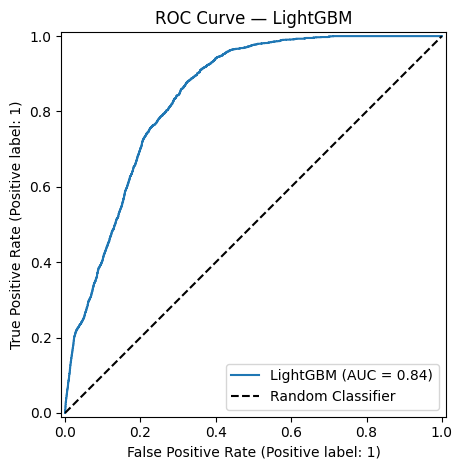

In [10]:
lgbm_params = {
    "n_estimators"  : 300,
    "max_depth"     : 5,
    "learning_rate" : 0.05,
    "subsample"     : 0.8,
    "random_state"  : 42,
    'class_weight'     :'balanced',
    "n_jobs"        : -1,
    "verbose"       : -1
}

with mlflow.start_run(run_name="LightGBM"):

    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)]
    )

    lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model(
        lgbm_model, X_test, y_test,
        model_name="LightGBM"
    )

    mlflow.log_params(lgbm_params)
    mlflow.log_metrics(lgbm_metrics)
    mlflow.lightgbm.log_model(lgbm_model, "lightgbm")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, lgbm_pred, "LightGBM")
plot_feature_importance(lgbm_model, X_train.columns.tolist(), "LightGBM")
plot_roc_curve(y_test, lgbm_prob, "LightGBM")

In [11]:
results = pd.DataFrame({
    'Model'    : [
        'Decision Tree',
        'Random Forest',
        'XGBoost Baseline',
        'XGBoost Tuned',
        'LightGBM'
    ],
    'Accuracy' : [
        dt_metrics['accuracy'],
        rf_metrics['accuracy'],
        xgb_base_metrics['accuracy'],
        xgb_tuned_metrics['accuracy'],
        lgbm_metrics['accuracy']
    ],
    'F1 Score' : [
        dt_metrics['f1_score'],
        rf_metrics['f1_score'],
        xgb_base_metrics['f1_score'],
        xgb_tuned_metrics['f1_score'],
        lgbm_metrics['f1_score']
    ],
    'Precision': [
        dt_metrics['precision'],
        rf_metrics['precision'],
        xgb_base_metrics['precision'],
        xgb_tuned_metrics['precision'],
        lgbm_metrics['precision']
    ],
    'Recall'   : [
        dt_metrics['recall'],
        rf_metrics['recall'],
        xgb_base_metrics['recall'],
        xgb_tuned_metrics['recall'],
        lgbm_metrics['recall']
    ],
    'ROC AUC'  : [
        dt_metrics['roc_auc'],
        rf_metrics['roc_auc'],
        xgb_base_metrics['roc_auc'],
        xgb_tuned_metrics['roc_auc'],
        lgbm_metrics['roc_auc']
    ]
})

#Highlight best value in each column
results = results.sort_values('Recall', ascending=False)
results = results.reset_index(drop=True)

print("\n" + "="*75)
print("  FINAL MODEL COMPARISON")
print("="*75)
print(results.to_string(index=False))
print("="*75)
print(f"\n🏆 Best Model by Recall: {results.iloc[0]['Model']}")


  FINAL MODEL COMPARISON
           Model  Accuracy  F1 Score  Precision  Recall  ROC AUC
   XGBoost Tuned    0.7117    0.3731     0.2390  0.8508   0.8435
        LightGBM    0.7113    0.3723     0.2384  0.8488   0.8425
XGBoost Baseline    0.7177    0.3724     0.2400  0.8304   0.8419
   Decision Tree    0.7259    0.3739     0.2429  0.8116   0.8360
   Random Forest    0.7252    0.3724     0.2419  0.8081   0.8317

🏆 Best Model by Recall: XGBoost Tuned


In [12]:
# Check correlation of every feature with target
correlations = X_train.copy()
correlations['escalated'] = y_train.values

corr_with_target = correlations.corr()['escalated'].drop('escalated')
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

print("Top 20 features correlated with escalated:")
print(corr_with_target.head(20))

Top 20 features correlated with escalated:
is_unresolved            0.186151
resolution_time_hours    0.120839
created_month            0.009524
weekday_num              0.007896
created_year             0.005068
priority                 0.004206
product_area             0.003068
issue_type               0.002897
reopened                 0.001235
has_attachment           0.001162
sla_plan                 0.000949
customer_segment         0.000425
Name: escalated, dtype: float64


In [13]:
#Map model name to actual trained object
model_map = {
    'Decision Tree'    : dt_model,
    'Random Forest'    : rf_model,
    'XGBoost Baseline' : xgb_baseline,
    'XGBoost Tuned'    : xgb_tuned,
    'LightGBM'         : lgbm_model
}

best_model_name = results.iloc[0]['Model']
best_model      = model_map[best_model_name]

In [14]:
joblib.dump(best_model, 'models/saved_models/best_tabular_model.pkl')
print("Best model saved ✅")

Best model saved ✅
